# 11.1 Multilayer perceptrons
## 11.1.1 Training an MLP for Iris Classification

Epoch [10/1000], Loss: 0.9458
Epoch [20/1000], Loss: 0.7637
Epoch [30/1000], Loss: 0.6632
Epoch [40/1000], Loss: 0.5451
Epoch [50/1000], Loss: 0.4704
Epoch [60/1000], Loss: 0.4928
Epoch [70/1000], Loss: 0.4028
Epoch [80/1000], Loss: 0.3252
Epoch [90/1000], Loss: 0.3339
Epoch [100/1000], Loss: 0.2804
Epoch [110/1000], Loss: 0.2797
Epoch [120/1000], Loss: 0.2780
Epoch [130/1000], Loss: 0.2388
Epoch [140/1000], Loss: 0.2343
Epoch [150/1000], Loss: 0.1873
Epoch [160/1000], Loss: 0.2052
Epoch [170/1000], Loss: 0.1743
Epoch [180/1000], Loss: 0.1669
Epoch [190/1000], Loss: 0.1517
Epoch [200/1000], Loss: 0.1554
Epoch [210/1000], Loss: 0.1342
Epoch [220/1000], Loss: 0.1248
Epoch [230/1000], Loss: 0.1185
Epoch [240/1000], Loss: 0.1145
Epoch [250/1000], Loss: 0.1069
Epoch [260/1000], Loss: 0.1175
Epoch [270/1000], Loss: 0.1293
Epoch [280/1000], Loss: 0.1031
Epoch [290/1000], Loss: 0.0945
Epoch [300/1000], Loss: 0.0882
Epoch [310/1000], Loss: 0.1191
Epoch [320/1000], Loss: 0.0959
Epoch [330/1000],

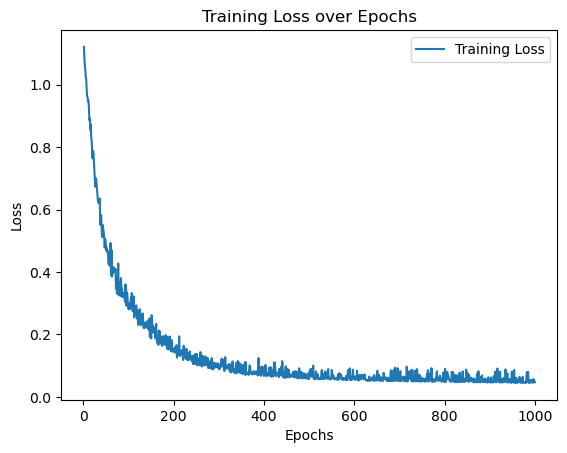

Test Accuracy: 100.00%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Step 1: Load and prepare the Iris dataset
iris = load_iris()
X = iris.data # Features (sepal length, sepal width, petal length, petal width)
y = iris.target # Target (species)

# Normalize the feature data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Construct PyTorch datasets
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)
train_dataset = TensorDataset(X_train, y_train)  # Combine features and targets
test_dataset = TensorDataset(X_test, y_test)

# Step 2: Define a simple MLP model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.mlp = nn.Sequential(nn.Linear(4, 16),
                                 nn.ReLU(),  # ReLU function
                                 nn.Linear(16, 3))

    def forward(self, x): # Forward pass
        x = self.mlp(x)
        return x

# Step 3: Initialize model, loss function, optimizer, and mini-batch dataloaders
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP().to(device) # Move model to device (GPU or CPU)
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.AdamW(model.parameters(), lr=0.001)  # Optimizer
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Step 4: Training loop
num_epochs = 1000
train_losses = []

for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0
    # Iterate over mini-batches
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)  # Move data to device
        optimizer.zero_grad()  # Zero the gradients
        output = model(data)  # Forward pass
        loss = criterion(output, target)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        running_loss += loss.item()  # Accumulate loss

    avg_loss = running_loss / len(train_loader)  # Average loss for the epoch
    train_losses.append(avg_loss)  # Store the average loss
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Step 5: Visualization of training loss
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

# Step 6: Evaluate the model on test data
model.eval()  # Set model to evaluation mode
correct = 0
total = 0
with torch.no_grad():  # No need to compute gradients during evaluation
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)  # Move data to device
        output = model(data)
        _, predicted = torch.max(output, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

accuracy = 100 * correct / len(y_test)
print(f'Test Accuracy: {accuracy:.2f}%')